
====== SMART EXPENSE TRACKER ======
1. Add Expense
2. View Summary
3. Filter Expenses
4. Generate Report
5. Visualize Expenses
6. Exit


Enter Your Choice :  1
Enter Date (YYYY-MM-DD):  2026-10-9
Enter Amount :  250
Enter Category :  Food
Enter Description :  Dinner


 Expense Added Successfully!

====== SMART EXPENSE TRACKER ======
1. Add Expense
2. View Summary
3. Filter Expenses
4. Generate Report
5. Visualize Expenses
6. Exit


Enter Your Choice :  2



========== SUMMARY ==========
Total Expense : 3050.0
Average Expense : 381.25
Maximum Expense : 500.0
Minimum Expense : 250.0

Category Wise Expense
Category
Food    3050.0
Name: Amount, dtype: float64

====== SMART EXPENSE TRACKER ======
1. Add Expense
2. View Summary
3. Filter Expenses
4. Generate Report
5. Visualize Expenses
6. Exit


...

Enter Choice :  1
Enter Category :  Dinner


Empty DataFrame
Columns: [Date, Amount, Category, Description]
Index: []

====== SMART EXPENSE TRACKER ======
1. Add Expense
2. View Summary
3. Filter Expenses
4. Generate Report
5. Visualize Expenses
6. Exit


Enter Your Choice :  4



========== REPORT ==========
          Date  Amount Category Description
0   2026-08-10   350.0     Food       Pizza
1   2026-08-10   350.0     Food       Pizza
2   2026-09-10   450.0     Food       Pizza
3   2026-09-15   500.0     Food      Dinner
4   2026-09-10   450.0     Food      Dinner
5   2026-10-09   350.0     Food      Dinner
6    2026-10-9   350.0     Food      Dinner
7    2026-10-9   250.0     Food      Dinner

Total Records : 8
Total Spending : 3050.0

Highest Expense
Date            2026-09-15
Amount               500.0
Category              Food
Description         Dinner
Name: 3, dtype: object

====== SMART EXPENSE TRACKER ======
1. Add Expense
2. View Summary
3. Filter Expenses
4. Generate Report
5. Visualize Expenses
6. Exit


Enter Your Choice :  5


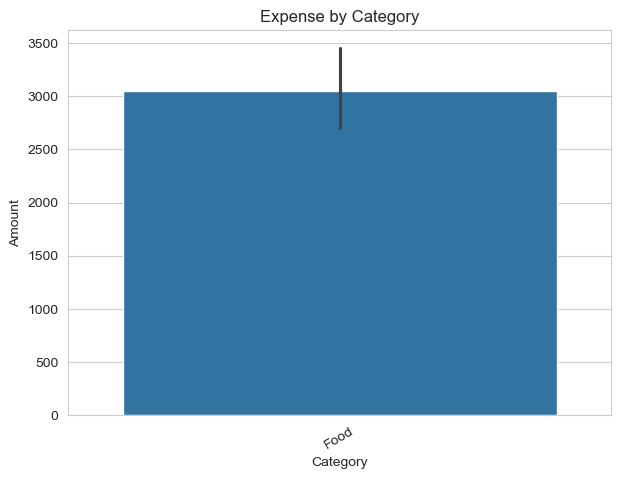

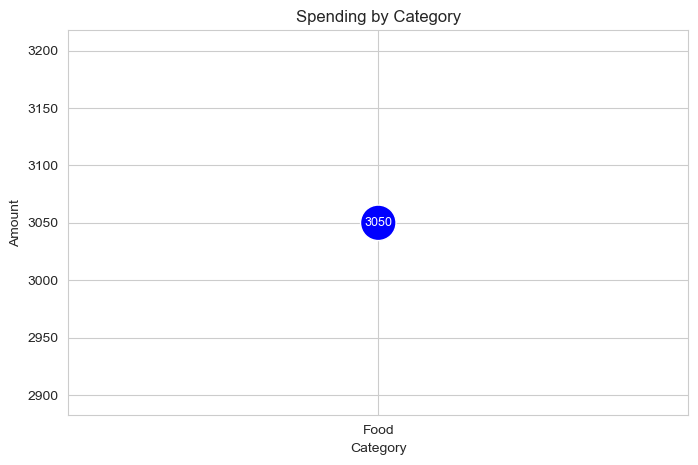

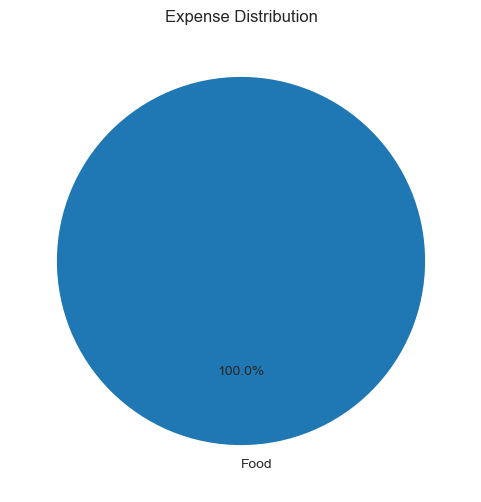

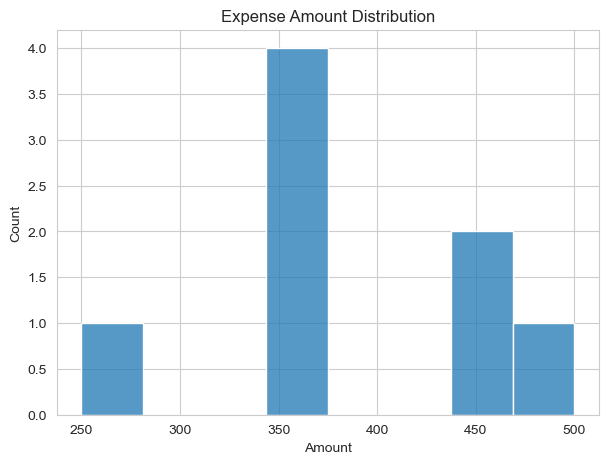


====== SMART EXPENSE TRACKER ======
1. Add Expense
2. View Summary
3. Filter Expenses
4. Generate Report
5. Visualize Expenses
6. Exit


Enter Your Choice :  6



Thank You! Visit Again.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

class ExpenseTracker:

    def __init__(self, filename="expenses.csv"):
        self.filename = filename

        if os.path.exists(filename):
            self.data = pd.read_csv(filename)
        else:
            self.data = pd.DataFrame(columns=[
                "Date", "Amount", "Category", "Description"
            ])
            self.data.to_csv(filename, index=False)

    # Add Expense
    def add_expense(self, date, amount, category, description):

        if amount <= 0:
            print(" Invalid Amount!")
            return

        categories = ["Food","Transport","Shopping",
                      "Utilities","Entertainment","Health","Education"]

        if category not in categories:
            print(" Invalid Category!")
            return

        new_expense = {
            "Date": date,
            "Amount": amount,
            "Category": category,
            "Description": description
        }

        self.data = pd.concat([self.data, pd.DataFrame([new_expense])], ignore_index=True)
        self.data.to_csv(self.filename, index=False)

        print(" Expense Added Successfully!")

    # Expense Summary
    def get_summary(self):

        if self.data.empty:
            print("No Expense Data Available.")
            return

        print("\n========== SUMMARY ==========")
        print("Total Expense :", np.sum(self.data["Amount"]))
        print("Average Expense :", round(np.mean(self.data["Amount"]),2))
        print("Maximum Expense :", np.max(self.data["Amount"]))
        print("Minimum Expense :", np.min(self.data["Amount"]))

        print("\nCategory Wise Expense")
        print(self.data.groupby("Category")["Amount"].sum())

    # Filter Expense
    def filter_expenses(self):

        print("\n1. Filter by Category")
        print("2. Filter by Date")

        choice = input("Enter Choice : ")

        if choice == "1":
            cat = input("Enter Category : ")
            print(self.data[self.data["Category"] == cat])

        elif choice == "2":
            date = input("Enter Date (YYYY-MM-DD): ")
            print(self.data[self.data["Date"] == date])

        else:
            print("Invalid Choice!")

    # Report
    def generate_report(self):

        if self.data.empty:
            print("No Expense Data Available.")
            return

        print("\n========== REPORT ==========")
        print(self.data)

        print("\nTotal Records :", len(self.data))
        print("Total Spending :", self.data["Amount"].sum())

        highest = self.data.loc[self.data["Amount"].idxmax()]
        print("\nHighest Expense")
        print(highest)

    # Visualization
    def visualize(self):

        if self.data.empty:
            print("No Expense Data Available.")
            return

        sns.set_style("whitegrid")

        # Bar Chart
        plt.figure(figsize=(7,5))
        sns.barplot(data=self.data, x="Category", y="Amount", estimator=sum)
        plt.title("Expense by Category")
        plt.xticks(rotation=30)
        plt.show()

        # Line Graph
        category_sum = self.data.groupby("Category")["Amount"].sum()

        plt.figure(figsize=(8,5))
        plt.plot(category_sum.index, category_sum.values,
                 marker="o", linewidth=3)

        # Number center me
        for x, y in zip(category_sum.index, category_sum.values):
            plt.text(x, y, str(int(y)),
                     ha="center",
                     va="center",
                     color="white",
                     fontsize=9,
                     bbox=dict(facecolor="blue", boxstyle="circle"))

        plt.title("Spending by Category")
        plt.xlabel("Category")
        plt.ylabel("Amount")
        plt.grid(True)
        plt.show()

        # Pie Chart
        plt.figure(figsize=(6,6))
        plt.pie(category_sum,
                labels=category_sum.index,
                autopct="%1.1f%%",
                startangle=90)
        plt.title("Expense Distribution")
        plt.show()

        # Histogram
        plt.figure(figsize=(7,5))
        sns.histplot(self.data["Amount"], bins=8)
        plt.title("Expense Amount Distribution")
        plt.xlabel("Amount")
        plt.show()


# ==========================
# Main Program
# ==========================

tracker = ExpenseTracker()

while True:

    print("\n====== SMART EXPENSE TRACKER ======")
    print("1. Add Expense")
    print("2. View Summary")
    print("3. Filter Expenses")
    print("4. Generate Report")
    print("5. Visualize Expenses")
    print("6. Exit")

    option = input("Enter Your Choice : ")

    if option == "1":

        date = input("Enter Date (YYYY-MM-DD): ")
        amount = float(input("Enter Amount : "))
        category = input("Enter Category : ")
        description = input("Enter Description : ")

        tracker.add_expense(date, amount, category, description)

    elif option == "2":
        tracker.get_summary()

    elif option == "3":
        tracker.filter_expenses()

    elif option == "4":
        tracker.generate_report()

    elif option == "5":
        tracker.visualize()

    elif option == "6":
        print("\nThank You! Visit Again.")
        break

    else:
        print(" Invalid Choice!")